# ECEN 740

## A Hands-On CIFAR-10 Project

**Total Marks: 100 + 5 Bonus**

---

### Project Overview

In this project, you will build, train, debug, and systematically improve a neural network for image classification on CIFAR-10. The project is structured as a series of experiments where you:

1. Start with a terrible model and diagnose why it fails.
2. Apply fixes one at a time and measure the impact of each.
3. Build intuition for *why* certain techniques work.
4. Combine everything into the best MLP you can design, documenting your approach.

### Rules
- Run every cell in order. Many cells depend on variables defined earlier.
- Do **NOT** change cells marked `DO NOT MODIFY` — these are test/validation cells.
- When asked to fill in code, look for the `YOUR CODE HERE` markers.
- Use a GPU runtime (`Runtime → Change runtime type → GPU`) for reasonable training times.

### Grading Breakdown

| Part | Topic | Marks |
|------|-------|-------|
| 1 | Data Exploration and Preprocessing | 6 |
| 2 | Your First (Broken) Classifier | 8 |
| 3 | Loss Functions: Cross-Entropy vs. Hinge | 10 |
| 4 | Optimizers: SGD, Momentum, and Adam | 10 |
| 5 | Backpropagation by Hand | 6 |
| 6 | Activation Functions and Dead Neurons | 10 |
| 7 | Weight Initialization — Why It Matters | 10 |
| 8 | Batch Normalization | 10 |
| 9 | Dropout and Regularization | 10 |
| 10 | Best MLP Challenge | 20 |
| **Total** | | **100** |
| **Bonus** | Reflection Questions | **5** |

In [4]:
!python -c "import torch; print(torch.__version__)"
!python -c "import torch; print(torch.cuda.is_available())"
!python -c "import torch; print(torch.cuda.device_count())"
!python -c "import torch; print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU')"
!python -m torch.utils.collect_env

2.10.0+rocm7.1
True
1
AMD Radeon RX 9070 XT
<frozen runpy>:128: RuntimeWarning: 'torch.utils.collect_env' found in sys.modules after import of package 'torch.utils', but prior to execution of 'torch.utils.collect_env'; this may result in unpredictable behaviour
PyTorch version: 2.10.0+rocm7.1
Is debug build: False
CUDA used to build PyTorch: N/A
ROCM used to build PyTorch: 7.1.25424

OS: Ubuntu 24.04.4 LTS (x86_64)
GCC version: (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
Clang version: Could not collect
CMake version: Could not collect
Libc version: glibc-2.39

Python version: 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0] (64-bit runtime)
Python platform: Linux-6.17.0-14-generic-x86_64-with-glibc2.39
Is CUDA available: True
CUDA runtime version: Could not collect
CUDA_MODULE_LOADING set to: 
GPU models and configuration: AMD Radeon RX 9070 XT (gfx1201)
Nvidia driver version: Could not collect
cuDNN version: Could not collect
Is XPU available: False
HIP runtime version: 7.1.25424
MIOpen

---
## Part 0: Setup and Imports

Run this cell first. It imports everything you need.

In [2]:
# DO NOT MODIFY
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import time
import copy
import math
from collections import defaultdict

torch.manual_seed(42)
np.random.seed(42)

# see if we can use amd gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print(f'Using device: {device}')
if device.type == 'mps':
    print(f'MPS: {torch.mps.is_available()}')

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

Using device: cuda


In [3]:
# DO NOT MODIFY — Utility functions used throughout the project

def train_one_epoch(model, trainloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0; correct = 0; total = 0
    for i, (inputs, labels) in enumerate(trainloader):            
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        if i == 0:
            print(f"inputs on device: {inputs.device}. labels on device: {labels.device}. model on device: {next(model.parameters()).device}")
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total

def evaluate(model, testloader, criterion, device):
    model.eval()
    running_loss = 0.0; correct = 0; total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total

def train_and_log(model, trainloader, testloader, criterion, optimizer,
                  epochs, device, scheduler=None, verbose=True):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, trainloader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, testloader, criterion, device)
        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        if scheduler is not None:
            scheduler.step()
        if verbose and (epoch % max(1, epochs // 10) == 0 or epoch == epochs - 1):
            print(f'Epoch {epoch+1:3d}/{epochs} | '
                  f'Train Loss {train_loss:.4f} Acc {train_acc:.1f}% | '
                  f'Val Loss {val_loss:.4f} Acc {val_acc:.1f}% | '
                  f'LR {current_lr:.6f}')
    return history

def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{title} — Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_multiple_histories(histories, labels, title='Comparison'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for h, label in zip(histories, labels):
        ax1.plot(h['train_loss'], label=f'{label}')
        ax2.plot(h['val_acc'], label=f'{label}')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Train Loss')
    ax1.set_title(f'{title} — Training Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Accuracy (%)')
    ax2.set_title(f'{title} — Validation Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

print('Utilities loaded.')

Utilities loaded.


---
## Part 1: Data Exploration and Preprocessing (6 marks)

Before building any model, you must understand your data. CIFAR-10 consists of 60,000 32×32 color images in 10 classes.

In [3]:
# DO NOT MODIFY — Load raw CIFAR-10
transform_basic = transforms.Compose([transforms.ToTensor()])
trainset_raw = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_basic)
testset_raw = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_basic)
print(f'Training set size: {len(trainset_raw)}')
print(f'Test set size: {len(testset_raw)}')
print(f'Image shape: {trainset_raw[0][0].shape}')

Training set size: 50000
Test set size: 10000
Image shape: torch.Size([3, 32, 32])


### Task 1.1 (2 marks): Visualize the data

Display a grid of 40 random images (4 per class) from the training set. Each image should have its class label as the title. Use `plt.subplots` to create a 4×10 grid.

**Important:** Call `plt.show()` at the end so the figure is finalized before the test cell runs.

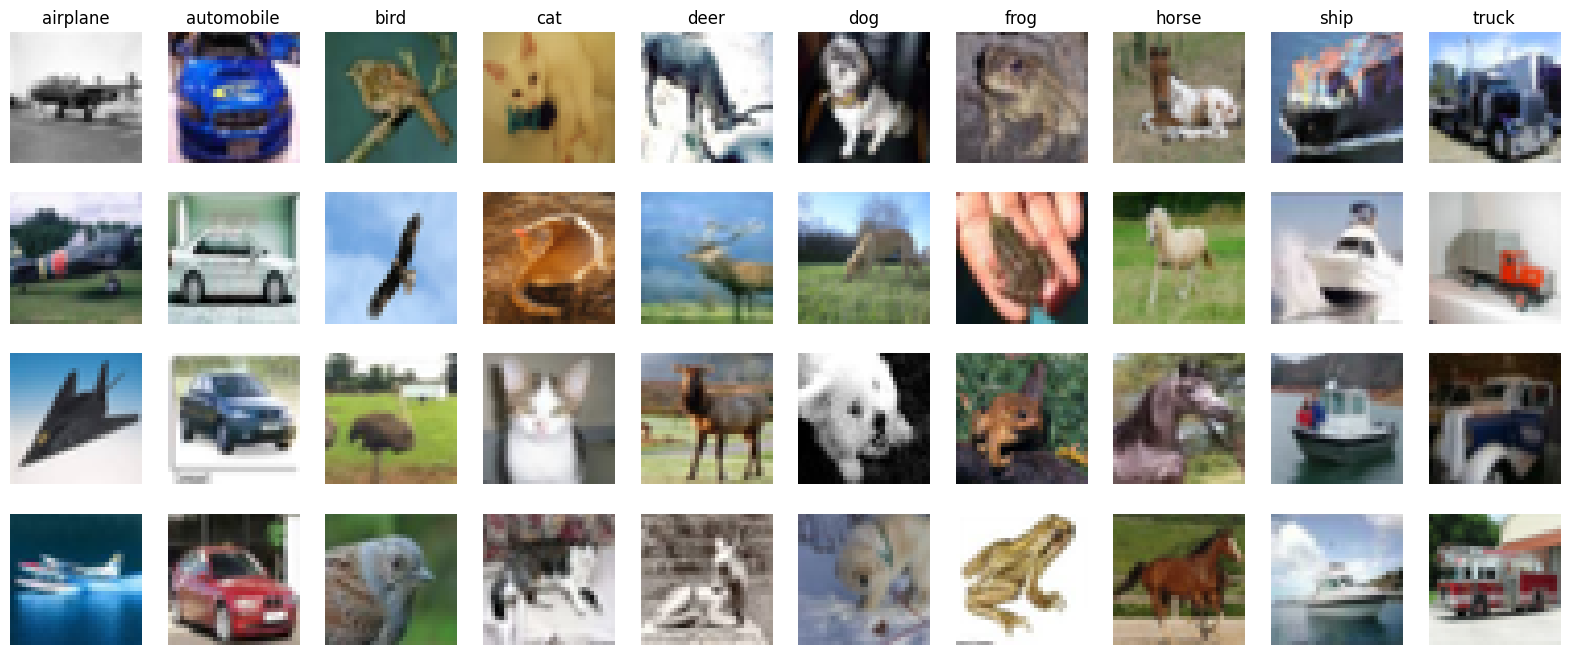

In [4]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import numpy as np
# YOUR CODE HERE
# Create a 4x10 grid showing 4 random samples from each of the 10 classes.
# Hint: use plt.subplots(4, 10, figsize=(20, 8))
# IMPORTANT: End your code with plt.show()

# Group indices by class
class_indices = {i: [] for i in range(10)}
for idx in range(len(trainset_raw)):
    _, label = trainset_raw[idx]
    class_indices[label].append(idx)

# Create the 4x10 grid
fig, axes = plt.subplots(4, 10, figsize=(20, 8))

# For each class (column), select 4 random samples (rows)
for class_idx in range(10):
    # Get 4 random indices for this class
    selected_indices = np.random.choice(class_indices[class_idx], size=4, replace=False)
    
    for row in range(4):
        img, _ = trainset_raw[selected_indices[row]]
        img = img.permute(1, 2, 0).numpy()
        
        axes[row, class_idx].imshow(img)
        axes[row, class_idx].axis('off')
        # Add class name as title only on first row
        if row == 0:
            axes[row, class_idx].set_title(CIFAR10_CLASSES[class_idx])

plt.show()


# END YOUR CODE

In [7]:
# DO NOT MODIFY — Test 1.1
fig = plt.gcf()
n_axes = len(fig.axes)
if n_axes == 0:
    all_figs = [plt.figure(i) for i in plt.get_fignums()]
    if all_figs:
        fig = all_figs[-1]
        n_axes = len(fig.axes)
assert n_axes >= 10, (
    f'Expected at least 10 subplots in your grid, got {n_axes}. '
    f'Make sure you use plt.subplots(4, 10, ...) and do NOT call plt.close().'
)
print(f'Test 1.1 PASSED: Grid visualization created with {n_axes} subplots.')

AssertionError: Expected at least 10 subplots in your grid, got 0. Make sure you use plt.subplots(4, 10, ...) and do NOT call plt.close().

<Figure size 640x480 with 0 Axes>

### Task 1.2 (2 marks): Compute per-channel statistics

Compute the mean and std of the entire training set for each of the 3 color channels (R, G, B). Store them in `channel_means` and `channel_stds` as tuples of length 3.

In [5]:
# YOUR CODE HERE

# Stack all images into a single tensor: (N, C, H, W)
all_images = torch.stack([trainset_raw[i][0] for i in range(len(trainset_raw))])

# Compute mean and std per channel (over N, H, W dimensions)
# all_images shape: (50000, 3, 32, 32)
channel_means = tuple(all_images.mean(dim=(0, 2, 3)).tolist())  # mean over batch, height, width
channel_stds = tuple(all_images.std(dim=(0, 2, 3)).tolist())    # std over batch, height, width

# END YOUR CODE

print(f'Channel means: {channel_means}')
print(f'Channel stds: {channel_stds}')

Channel means: (0.491400808095932, 0.48215898871421814, 0.44653093814849854)
Channel stds: (0.24703224003314972, 0.24348513782024384, 0.26158785820007324)


In [6]:
# DO NOT MODIFY — Test 1.2
assert channel_means is not None and channel_stds is not None
assert len(channel_means) == 3 and len(channel_stds) == 3
assert abs(channel_means[0] - 0.4914) < 0.01, f'Red channel mean looks off: {channel_means[0]:.4f}'
assert abs(channel_stds[0] - 0.2470) < 0.02, f'Red channel std looks off: {channel_stds[0]:.4f}'
print('Test 1.2 PASSED: Channel statistics are correct.')

Test 1.2 PASSED: Channel statistics are correct.


### Task 1.3 (2 marks): Create data loaders with normalization and augmentation

Create two transform pipelines:
1. `transform_train`: RandomCrop(32, padding=4), RandomHorizontalFlip, ToTensor, Normalize
2. `transform_test`: ToTensor, Normalize

Then create datasets and dataloaders with `batch_size=128`.

In [7]:
# YOUR CODE HERE

# Define transform pipelines using the computed channel statistics
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(channel_means, channel_stds)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(channel_means, channel_stds)
])

# Create datasets with the new transforms
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Create data loaders with batch_size=128
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=4)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=4)

# END YOUR CODE

In [9]:
# DO NOT MODIFY — Test 1.3
batch = next(iter(trainloader))
assert batch[0].shape == torch.Size([128, 3, 32, 32]), f'Unexpected batch shape: {batch[0].shape}'
assert batch[0].mean().abs() < 1.0, 'Data does not appear to be normalized.'
print('Test 1.3 PASSED: Data loaders created with normalization.')

Test 1.3 PASSED: Data loaders created with normalization.


---
## Part 2: Your First (Broken) Classifier (8 marks)

In [12]:
# DO NOT MODIFY — A deliberately terrible classifier
class LinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(3 * 32 * 32, 10)
    def forward(self, x):
        return self.fc(self.flatten(x))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_broken = LinearClassifier().to(device)
optimizer_broken = optim.SGD(model_broken.parameters(), lr=10.0)
criterion = nn.CrossEntropyLoss()
print('Training a linear classifier with lr=10.0 ...')
history_broken = train_and_log(model_broken, trainloader, testloader, criterion,
                               optimizer_broken, epochs=5, device=device)

Training a linear classifier with lr=10.0 ...
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   1/5 | Train Loss 1112.8164 Acc 20.4% | Val Loss 771.2491 Acc 24.1% | LR 10.000000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   2/5 | Train Loss 1031.4306 Acc 21.0% | Val Loss 2032.1313 Acc 19.9% | LR 10.000000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   3/5 | Train Loss 1046.1214 Acc 21.6% | Val Loss 1051.7646 Acc 21.4% | LR 10.000000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   4/5 | Train Loss 1026.8987 Acc 21.4% | Val Loss 1342.3065 Acc 21.0% | LR 10.000000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   5/5 | Train Loss 1035.5249 Acc 21.7% | Val Loss 1168.2221 Acc 19.3% | LR 10.000000


### Task 2.1 (3 marks): Diagnose and fix the linear classifier

The model above likely produced NaN losses or random-chance accuracy. Fix it by choosing a reasonable learning rate, and train for 10 epochs. Store the result in `history_fixed_linear`.

In [13]:
# YOUR CODE HERE
lr = 1e-3
criterion = nn.CrossEntropyLoss()

model_linear = LinearClassifier().to(device)
optimizer_linear = None  # Choose a reasonable optimizer and lr
optimizer_linear = optim.SGD(params = model_linear.parameters(), lr = 1e-3)
print('Training a linear classifier with lr=1e-3 ...')
history_fixed_linear = train_and_log(model_linear, trainloader, testloader, criterion, optimizer_linear, epochs=10, device=device)

# END YOUR CODE

Training a linear classifier with lr=1e-3 ...
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   1/10 | Train Loss 2.0634 Acc 25.4% | Val Loss 1.9476 Acc 31.5% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   2/10 | Train Loss 1.9613 Acc 30.1% | Val Loss 1.9121 Acc 32.5% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   3/10 | Train Loss 1.9327 Acc 31.6% | Val Loss 1.8935 Acc 34.1% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   4/10 | Train Loss 1.9199 Acc 32.2% | Val Loss 1.8805 Acc 34.6% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   5/10 | Train Loss 1.9113 Acc 32.7% | Val Loss 1.8711 Acc 34.9% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   6/10 | Train Loss 1.9015 Acc 32.8% | Val Loss 1.8702 Acc 35.0% | 

In [14]:
# DO NOT MODIFY — Test 2.1
assert history_fixed_linear is not None
final_acc = history_fixed_linear['val_acc'][-1]
assert final_acc > 20.0, f'Linear classifier should get >20% accuracy, got {final_acc:.1f}%'
assert not any(np.isnan(history_fixed_linear['train_loss'])), 'Training loss contains NaN!'
print(f'Test 2.1 PASSED: Linear classifier achieved {final_acc:.1f}% val accuracy.')

Test 2.1 PASSED: Linear classifier achieved 35.6% val accuracy.


### Task 2.2 (3 marks): Add hidden layers

Build a simple MLP:
- `Flatten → Linear(3072, 512) → ReLU → Linear(512, 256) → ReLU → Linear(256, 10)`

Train for 20 epochs with an appropriate optimizer.

In [15]:
# YOUR CODE HERE

class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear( 3072, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(256, 10)


    def forward(self, x : torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x
lr: float = 1e-3
criterion = nn.CrossEntropyLoss()
model_mlp = SimpleMLP().to(device)
optimizer_mlp = optim.Adam(model_mlp.parameters(), lr=lr)
history_mlp = train_and_log(model_mlp, trainloader, testloader, criterion, optimizer_mlp, epochs=20, device=device)

# END YOUR CODE

inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   1/20 | Train Loss 1.7920 Acc 35.4% | Val Loss 1.6801 Acc 39.4% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   3/20 | Train Loss 1.5586 Acc 44.1% | Val Loss 1.6029 Acc 42.6% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   5/20 | Train Loss 1.4848 Acc 46.7% | Val Loss 1.5640 Acc 43.9% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   7/20 | Train Loss 1.4419 Acc 48.2% | Val Loss 1.5608 Acc 44.4% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. 

Test 2.2 PASSED: MLP (46.8%) outperforms linear (35.6%).


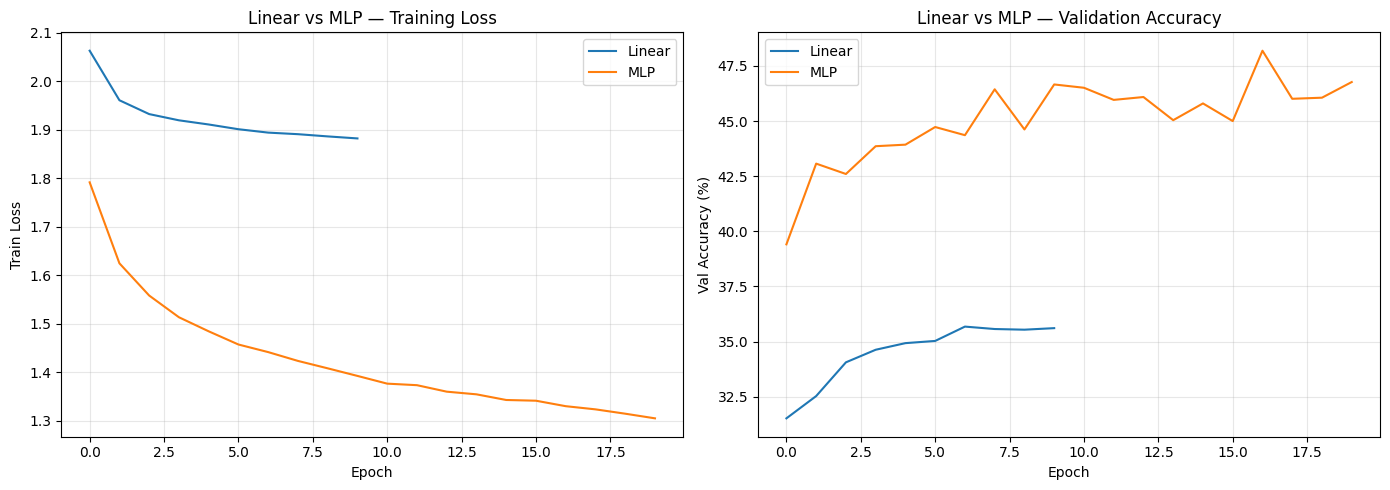

In [16]:
# DO NOT MODIFY — Test 2.2
assert history_mlp is not None
mlp_acc = history_mlp['val_acc'][-1]
linear_acc = history_fixed_linear['val_acc'][-1]
assert mlp_acc > linear_acc, f'MLP ({mlp_acc:.1f}%) should outperform linear ({linear_acc:.1f}%)'
assert mlp_acc > 40.0, f'MLP should get >40%, got {mlp_acc:.1f}%'
print(f'Test 2.2 PASSED: MLP ({mlp_acc:.1f}%) outperforms linear ({linear_acc:.1f}%).')
plot_multiple_histories([history_fixed_linear, history_mlp], ['Linear', 'MLP'], 'Linear vs MLP')

### Task 2.3 (2 marks): Count parameters

Write a function `count_parameters(model)` that returns the total number of trainable parameters.

In [17]:
# YOUR CODE HERE

def count_parameters(model : nn.Module) -> int:
    total_params = 0
    for param in model.parameters():
        print(param.size())
        total_params += param.numel()
    return total_params
        
    pass

# END YOUR CODE

print(f'LinearClassifier: {count_parameters(LinearClassifier()):,} parameters')
print(f'SimpleMLP: {count_parameters(SimpleMLP()):,} parameters')

torch.Size([10, 3072])
torch.Size([10])
LinearClassifier: 30,730 parameters
torch.Size([512, 3072])
torch.Size([512])
torch.Size([256, 512])
torch.Size([256])
torch.Size([10, 256])
torch.Size([10])
SimpleMLP: 1,707,274 parameters


In [18]:
# DO NOT MODIFY — Test 2.3
n_params = count_parameters(SimpleMLP())
assert 1_500_000 < n_params < 2_000_000, f'SimpleMLP should have ~1.7M params, got {n_params:,}'
print(f'Test 2.3 PASSED: SimpleMLP has {n_params:,} parameters.')

torch.Size([512, 3072])
torch.Size([512])
torch.Size([256, 512])
torch.Size([256])
torch.Size([10, 256])
torch.Size([10])
Test 2.3 PASSED: SimpleMLP has 1,707,274 parameters.


---
## Part 3: Loss Functions: Cross-Entropy vs. Hinge (10 marks)

### Task 3.1 (4 marks): Implement multi-class hinge loss

Implement `MultiClassHingeLoss` as a PyTorch module. For a single sample with scores **s** and correct class *y*:

$$L = \sum_{j \neq y} \max(0, s_j - s_y + \Delta)$$

where Δ is the margin (default 1.0). The batch loss should be the mean over samples.

In [23]:
# YOUR CODE HERE
class MultiClassHingeLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin
    def forward(self, scores, labels):
        # scores: (N, C), labels: (N,)
        batch_size = scores.size(0)
        # scores of the correct class: shape (N, 1)
        correct_scores = scores.gather(1, labels.view(-1, 1))
        # margins for all classes
        margins = scores - correct_scores + self.margin
        # do not count the correct class in the loss
        margins[torch.arange(batch_size), labels] = 0.0
        # hinge: max(0, margin)
        margins = torch.clamp(margins, min=0.0)
        # sum over classes, then mean over batch
        loss = margins.sum(dim=1).mean()
        return loss

# END YOUR CODE

In [24]:
# DO NOT MODIFY — Test 3.1
hinge_loss_fn = MultiClassHingeLoss(margin=1.0)
test_scores = torch.tensor([[3.2, 5.1, -1.7]])
test_labels = torch.tensor([0])
loss_val = hinge_loss_fn(test_scores, test_labels).item()
assert abs(loss_val - 2.9) < 0.01, f'Expected 2.9, got {loss_val:.4f}'
test_scores2 = torch.tensor([[10.0, 1.0, 1.0]])
loss_val2 = hinge_loss_fn(test_scores2, torch.tensor([0])).item()
assert abs(loss_val2) < 0.01, f'Expected 0, got {loss_val2:.4f}'
print('Test 3.1 PASSED: Hinge loss implementation correct.')

Test 3.1 PASSED: Hinge loss implementation correct.


### Task 3.2 (3 marks): Train with both losses and compare

Train two identical `SimpleMLP` models for 20 epochs:
- One with `nn.CrossEntropyLoss`
- One with your `MultiClassHingeLoss`

Use the same optimizer (`SGD`, lr=0.01, momentum=0.9) for both.

In [25]:
# YOUR CODE HERE
from torch.optim import SGD


model_ce = SimpleMLP().to(device)
loss_ce = nn.CrossEntropyLoss()
optimze_ce = SGD(model_ce.parameters(), lr=0.01, momentum=0.9)
history_ce = train_and_log(model_ce, trainloader, testloader, loss_ce, optimze_ce, epochs=20, device=device)


model_hinge = SimpleMLP().to(device)
loss_hinge = MultiClassHingeLoss(margin=1.0)
optimzer_hinge = SGD(model_hinge.parameters(), lr=0.01, momentum=0.9)
history_hinge = train_and_log(model_hinge, trainloader, testloader, loss_hinge, optimzer_hinge, epochs=20, device=device)

# END YOUR CODE

inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   1/20 | Train Loss 1.8368 Acc 33.3% | Val Loss 1.6710 Acc 40.4% | LR 0.010000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   3/20 | Train Loss 1.5723 Acc 43.5% | Val Loss 1.5188 Acc 46.0% | LR 0.010000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   5/20 | Train Loss 1.4845 Acc 46.7% | Val Loss 1.4888 Acc 47.1% | LR 0.010000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   7/20 | Train Loss 1.4305 Acc 48.5% | Val Loss 1.4416 Acc 49.1% | LR 0.010000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. 

Cross-Entropy final val acc: 51.9%
Hinge Loss final val acc: 31.9%


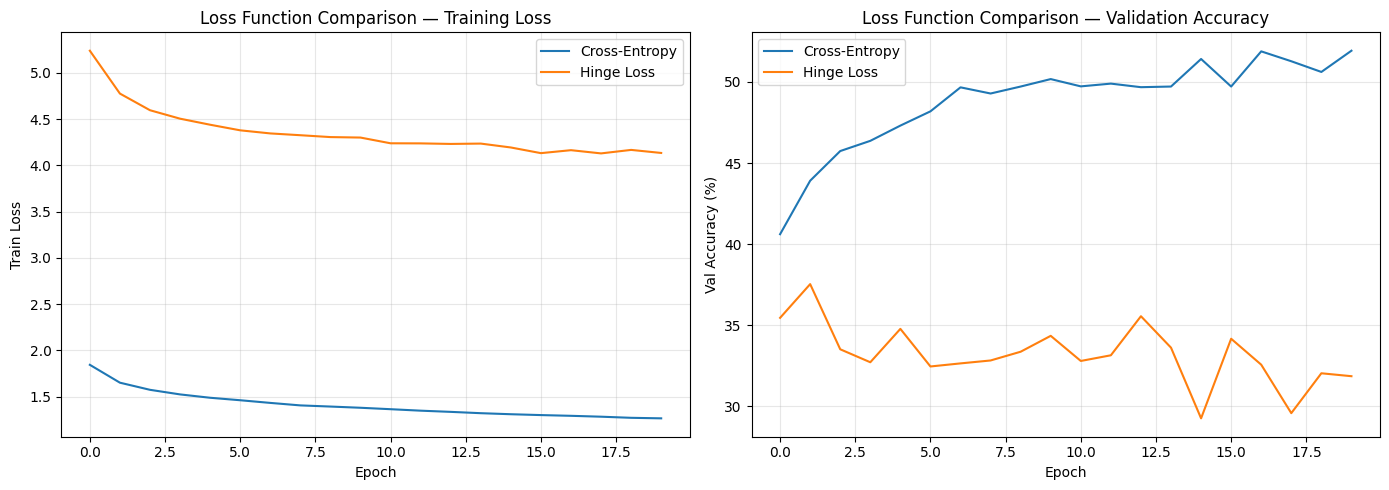

Test 3.2 PASSED.


In [ ]:
# DO NOT MODIFY — Test 3.2
assert history_ce is not None and history_hinge is not None
assert len(history_ce['val_acc']) == 20
print(f'Cross-Entropy final val acc: {history_ce["val_acc"][-1]:.1f}%')
print(f'Hinge Loss final val acc: {history_hinge["val_acc"][-1]:.1f}%')
plot_multiple_histories([history_ce, history_hinge],
                       ['Cross-Entropy', 'Hinge Loss'], 'Loss Function Comparison')
print('Test 3.2 PASSED.')

### Task 3.3 (3 marks): Visualize the confidence distributions

After training, run both models on the test set. For each model, collect the softmax probability assigned to the **true class** for all test samples. Plot two histograms side by side.

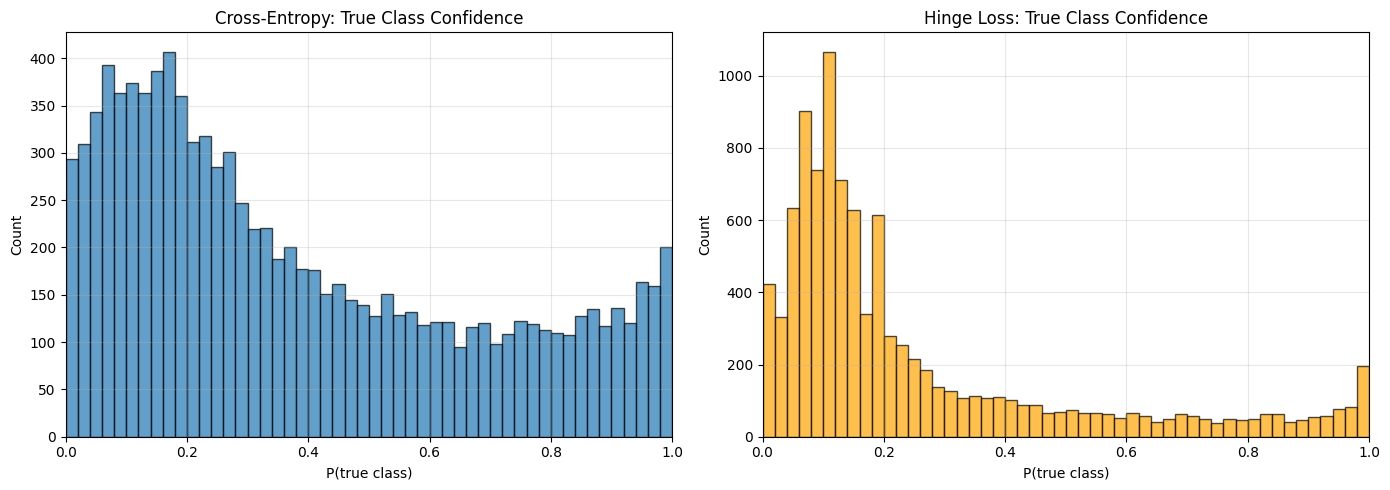

In [26]:
# YOUR CODE HERE
# For each model (model_ce, model_hinge):
# 1. Run inference on testloader
# 2. Apply softmax to outputs
# 3. Collect P(true_class) for each sample
# 4. Plot two histograms side by side

def get_true_class_probs(model, testloader, device):
    """Run model on test set and return P(true_class) for each sample."""
    model.eval()
    true_class_probs = []
    
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            # Apply softmax to get probabilities
            probs = F.softmax(outputs, dim=1)
            # Get probability of the true class for each sample
            batch_true_probs = probs[torch.arange(len(labels)), labels]
            true_class_probs.append(batch_true_probs.cpu())
    
    return torch.cat(true_class_probs).numpy()

# Get probabilities for both models
ce_probs = get_true_class_probs(model_ce, testloader, device)
hinge_probs = get_true_class_probs(model_hinge, testloader, device)

# Plot two histograms side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(ce_probs, bins=50, edgecolor='black', alpha=0.7)
ax1.set_xlabel('P(true class)')
ax1.set_ylabel('Count')
ax1.set_title('Cross-Entropy: True Class Confidence')
ax1.set_xlim(0, 1)
ax1.grid(True, alpha=0.3)

ax2.hist(hinge_probs, bins=50, edgecolor='black', alpha=0.7, color='orange')
ax2.set_xlabel('P(true class)')
ax2.set_ylabel('Count')
ax2.set_title('Hinge Loss: True Class Confidence')
ax2.set_xlim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# END YOUR CODE

---
## Part 4: Optimizers: SGD, Momentum, and Adam (10 marks)

### Task 4.1 (4 marks): Optimizer comparison experiment

Train three identical `SimpleMLP` models for 20 epochs each:
1. **SGD** (lr=0.01, no momentum)
2. **SGD with Momentum** (lr=0.01, momentum=0.9)
3. **Adam** (lr=0.001)

Use cross-entropy loss for all three.

In [27]:
# YOUR CODE HERE
from torch.optim import SGD, Adam

model_sgd = SimpleMLP().to(device)
loss_ce = nn.CrossEntropyLoss()
optimizer_sgd = SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
history_sgd = train_and_log(model_sgd, trainloader, testloader, loss_ce, optimizer_sgd, epochs=20, device=device)

model_momentum = SimpleMLP().to(device)
loss_ce = nn.CrossEntropyLoss()
optimizer_momentum = SGD(model_momentum.parameters(), lr=0.01, momentum=0.9)
history_momentum = train_and_log(model_momentum, trainloader, testloader, loss_ce, optimizer_momentum, epochs=20, device=device)

model_adam = SimpleMLP().to(device)
loss_ce = nn.CrossEntropyLoss()
optimizer_adam = Adam(model_adam.parameters(), lr=0.001)
history_adam = train_and_log(model_adam, trainloader, testloader, loss_ce, optimizer_adam, epochs=20, device=device)

# END YOUR CODE

inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   1/20 | Train Loss 1.8453 Acc 33.3% | Val Loss 1.6662 Acc 40.8% | LR 0.010000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   3/20 | Train Loss 1.5768 Acc 43.2% | Val Loss 1.5019 Acc 46.3% | LR 0.010000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   5/20 | Train Loss 1.4873 Acc 46.6% | Val Loss 1.4852 Acc 47.1% | LR 0.010000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   7/20 | Train Loss 1.4302 Acc 48.7% | Val Loss 1.4340 Acc 49.3% | LR 0.010000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. 

SGD: 51.1%  Momentum: 51.2%  Adam: 46.7%


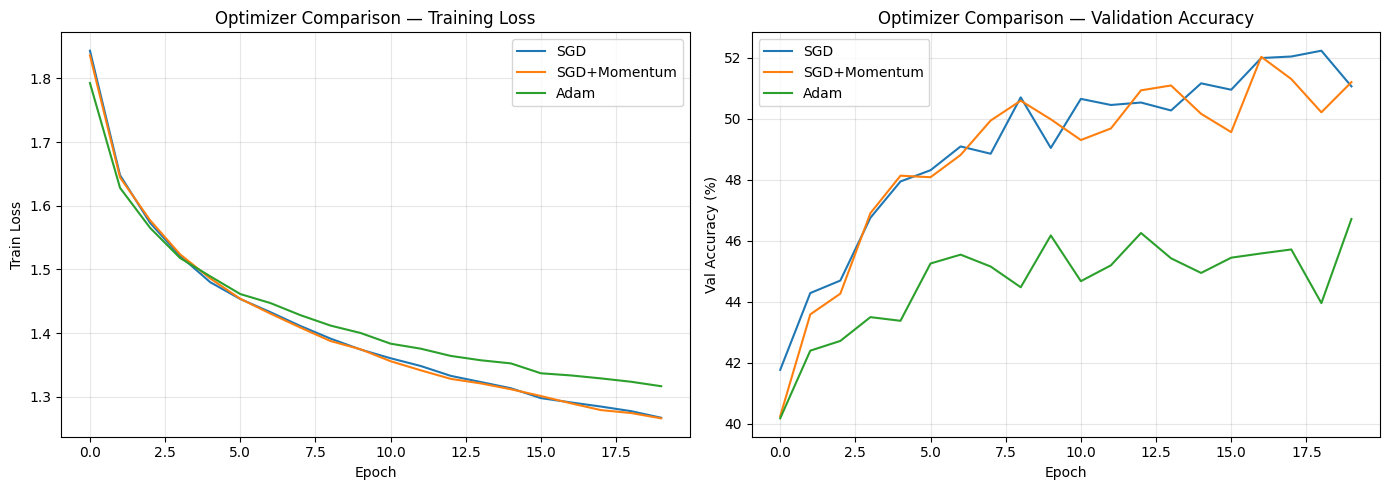

Test 4.1 PASSED.


In [ ]:
# DO NOT MODIFY — Test 4.1
assert all(h is not None for h in [history_sgd, history_momentum, history_adam])
sgd_acc = history_sgd['val_acc'][-1]
mom_acc = history_momentum['val_acc'][-1]
adam_acc = history_adam['val_acc'][-1]
print(f'SGD: {sgd_acc:.1f}%  Momentum: {mom_acc:.1f}%  Adam: {adam_acc:.1f}%')
assert mom_acc > sgd_acc - 5, 'Momentum should generally improve over plain SGD.'
plot_multiple_histories([history_sgd, history_momentum, history_adam],
                       ['SGD', 'SGD+Momentum', 'Adam'], 'Optimizer Comparison')
print('Test 4.1 PASSED.')

### Task 4.2 (6 marks): Visualize optimizer trajectories on a 2D loss surface

Optimize a simple 2D function:

$$f(x, y) = 0.1 \cdot x^2 + 2.0 \cdot y^2$$

This is a long, narrow valley (eigenvalues differ by 20×). Starting from (5, 5), run 50 steps of each optimizer and plot trajectories on a contour plot.

**Steps:**
1. Implement `run_optimizer_2d` that minimizes the function and returns `(x, y)` positions
2. Run with SGD (lr=0.1), SGD+Momentum (lr=0.1, momentum=0.9), and Adam (lr=0.5)
3. Plot trajectories on top of a contour plot

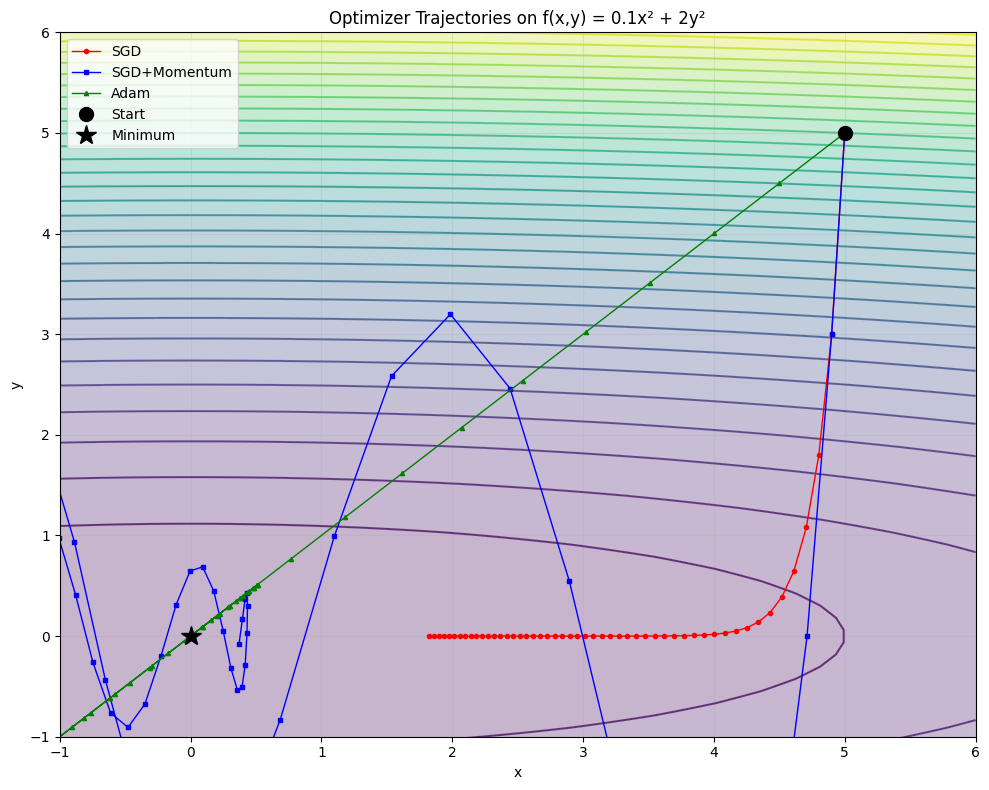

In [ ]:
# YOUR CODE HERE

def run_optimizer_2d(optimizer_class, optimizer_kwargs, start=(5.0, 5.0), steps=50):
    """Minimize f(x,y) = 0.1*x^2 + 2*y^2 starting from `start`.
    Returns: list of (x, y) positions at each step."""
    # Create tensors with gradients
    x = torch.tensor(start[0], requires_grad=True)
    y = torch.tensor(start[1], requires_grad=True)
    
    # Create optimizer with the parameters
    optimizer = optimizer_class([x, y], **optimizer_kwargs)
    
    positions = [(x.item(), y.item())]
    
    for _ in range(steps):
        optimizer.zero_grad()
        # Compute the loss: f(x,y) = 0.1*x^2 + 2*y^2
        loss = 0.1 * x**2 + 2.0 * y**2
        loss.backward()
        optimizer.step()
        positions.append((x.item(), y.item()))
    
    return positions

# Run optimizers
traj_sgd = run_optimizer_2d(optim.SGD, {'lr': 0.1}, start=(5.0, 5.0), steps=50)
traj_mom = run_optimizer_2d(optim.SGD, {'lr': 0.1, 'momentum': 0.9}, start=(5.0, 5.0), steps=50)
traj_adam = run_optimizer_2d(optim.Adam, {'lr': 0.5}, start=(5.0, 5.0), steps=50)

# Plot contour + trajectories
fig, ax = plt.subplots(figsize=(10, 8))

# Create contour plot
x_range = np.linspace(-6, 6, 100)
y_range = np.linspace(-6, 6, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = 0.1 * X**2 + 2.0 * Y**2

ax.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.7)
ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.3)

# Plot trajectories
traj_sgd = np.array(traj_sgd)
traj_mom = np.array(traj_mom)
traj_adam = np.array(traj_adam)

ax.plot(traj_sgd[:, 0], traj_sgd[:, 1], 'ro-', label='SGD', markersize=3, linewidth=1)
ax.plot(traj_mom[:, 0], traj_mom[:, 1], 'bs-', label='SGD+Momentum', markersize=3, linewidth=1)
ax.plot(traj_adam[:, 0], traj_adam[:, 1], 'g^-', label='Adam', markersize=3, linewidth=1)

# Mark start and end points
ax.plot(5, 5, 'ko', markersize=10, label='Start')
ax.plot(0, 0, 'k*', markersize=15, label='Minimum')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Optimizer Trajectories on f(x,y) = 0.1x² + 2y²')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 6)

plt.tight_layout()

# END YOUR CODE

In [ ]:
# DO NOT MODIFY — Test 4.2
assert traj_sgd is not None and len(traj_sgd) > 10
sgd_final = np.sqrt(traj_sgd[-1][0]**2 + traj_sgd[-1][1]**2)
mom_final = np.sqrt(traj_mom[-1][0]**2 + traj_mom[-1][1]**2)
adam_final = np.sqrt(traj_adam[-1][0]**2 + traj_adam[-1][1]**2)
print(f'Final distance from origin — SGD: {sgd_final:.4f}, Momentum: {mom_final:.4f}, Adam: {adam_final:.4f}')
print('Test 4.2 PASSED.')

Final distance from origin — SGD: 1.8208, Momentum: 0.3783, Adam: 0.0341
Test 4.2 PASSED.


---
## Part 5: Backpropagation by Hand (6 marks)

### Task 5.1 (3 marks): Verify backpropagation through a sigmoid neuron

Consider: $f = \sigma(w_0 x_0 + w_1 x_1 + w_2)$ with values:
- $w_0 = 2,\ x_0 = -1,\ w_1 = -3,\ x_1 = -2,\ w_2 = -3$

Use PyTorch autograd to compute all five first-order gradients and print them.

In [ ]:
# YOUR CODE HERE

# Define variables with requires_grad=True
w0 = torch.tensor(2.0, requires_grad=True)
x0 = torch.tensor(-1.0, requires_grad=True)
w1 = torch.tensor(-3.0, requires_grad=True)
x1 = torch.tensor(-2.0, requires_grad=True)
w2 = torch.tensor(-3.0, requires_grad=True)

# Compute f = sigmoid(w0*x0 + w1*x1 + w2)
f = torch.sigmoid(w0*x0 + w1*x1 + w2)

# Backpropagate to compute gradients
f.backward()

# Print all gradients
print(f'f = {f.item():.6f}')
print(f'df/dw0 = {w0.grad.item():.6f}')
print(f'df/dx0 = {x0.grad.item():.6f}')
print(f'df/dw1 = {w1.grad.item():.6f}')
print(f'df/dx1 = {x1.grad.item():.6f}')
print(f'df/dw2 = {w2.grad.item():.6f}')

# END YOUR CODE

f = 0.731059
df/dw0 = -0.196612
df/dx0 = 0.393224
df/dw1 = -0.393224
df/dx1 = -0.589836
df/dw2 = 0.196612


In [ ]:
# DO NOT MODIFY — Test 5.1
w0 = torch.tensor(2.0, requires_grad=True)
x0 = torch.tensor(-1.0, requires_grad=True)
w1 = torch.tensor(-3.0, requires_grad=True)
x1 = torch.tensor(-2.0, requires_grad=True)
w2 = torch.tensor(-3.0, requires_grad=True)
f = torch.sigmoid(w0*x0 + w1*x1 + w2)
f.backward()
assert abs(w0.grad.item() - (-0.197)) < 0.01, f'df/dw0 wrong: {w0.grad.item():.4f}'
assert abs(x0.grad.item() - 0.393) < 0.01, f'df/dx0 wrong: {x0.grad.item():.4f}'
assert abs(w1.grad.item() - (-0.393)) < 0.01, f'df/dw1 wrong: {w1.grad.item():.4f}'
assert abs(x1.grad.item() - (-0.590)) < 0.01, f'df/dx1 wrong: {x1.grad.item():.4f}'
assert abs(w2.grad.item() - 0.197) < 0.01, f'df/dw2 wrong: {w2.grad.item():.4f}'
print('Test 5.1 PASSED: Backpropagation values are correct.')

Test 5.1 PASSED: Backpropagation values are correct.


### Task 5.2 (3 marks): Manual backward pass through a two-layer network

Given `x → (W1, b1) → ReLU → (W2, b2) → scores`, implement the backward pass **manually** (without autograd) and verify your gradients match PyTorch's.

**Steps:**
1. Compute forward pass manually (store intermediates)
2. Compute gradients of `scores[0]` w.r.t. W1, b1, W2, b2
3. Verify against `.backward()`

In [ ]:
# YOUR CODE HERE

torch.manual_seed(0)
x_bp = torch.randn(4)
W1_bp = torch.randn(3, 4, requires_grad=True)
b1_bp = torch.randn(3, requires_grad=True)
W2_bp = torch.randn(2, 3, requires_grad=True)
b2_bp = torch.randn(2, requires_grad=True)

# Step 1: Manual forward pass (store intermediates)
z1 = W1_bp @ x_bp + b1_bp          # (3,) pre-activation
a1 = torch.relu(z1)                 # (3,) post-ReLU activation
scores = W2_bp @ a1 + b2_bp         # (2,) output scores

# Step 2: Manual backward pass for L = scores[0]
# Gradient of loss w.r.t. scores: only scores[0] contributes
dL_dscores = torch.tensor([1.0, 0.0])  # (2,)

# Gradients for layer 2
dL_db2_manual = dL_dscores.clone()                              # (2,)
dL_dW2_manual = dL_dscores.view(-1, 1) @ a1.view(1, -1)         # (2, 3) outer product

# Backprop through layer 2 to get gradient w.r.t. a1
dL_da1 = W2_bp.T @ dL_dscores                                   # (3,)

# Backprop through ReLU: gradient is 0 where z1 <= 0
dL_dz1 = dL_da1 * (z1 > 0).float()                              # (3,)

# Gradients for layer 1
dL_db1_manual = dL_dz1.clone()                                  # (3,)
dL_dW1_manual = dL_dz1.view(-1, 1) @ x_bp.view(1, -1)           # (3, 4) outer product

# Step 3: Autograd verification
# Recompute forward pass for autograd (need fresh computation graph)
z1_auto = W1_bp @ x_bp + b1_bp
a1_auto = torch.relu(z1_auto)
scores_auto = W2_bp @ a1_auto + b2_bp
scores_auto[0].backward()

# Compare manual vs autograd
print("=== Gradient Comparison ===")
print(f"dL/dW2 match: {torch.allclose(dL_dW2_manual, W2_bp.grad)}")
print(f"dL/db2 match: {torch.allclose(dL_db2_manual, b2_bp.grad)}")
print(f"dL/dW1 match: {torch.allclose(dL_dW1_manual, W1_bp.grad)}")
print(f"dL/db1 match: {torch.allclose(dL_db1_manual, b1_bp.grad)}")

print("\n=== Manual Gradients ===")
print(f"dL/dW2:\n{dL_dW2_manual}")
print(f"dL/db2: {dL_db2_manual}")
print(f"dL/dW1:\n{dL_dW1_manual}")
print(f"dL/db1: {dL_db1_manual}")

print("\n=== Autograd Gradients ===")
print(f"W2.grad:\n{W2_bp.grad}")
print(f"b2.grad: {b2_bp.grad}")
print(f"W1.grad:\n{W1_bp.grad}")
print(f"b1.grad: {b1_bp.grad}")

# END YOUR CODE

=== Gradient Comparison ===
dL/dW2 match: True
dL/db2 match: True
dL/dW1 match: True
dL/db1 match: True

=== Manual Gradients ===
dL/dW2:
tensor([[0.0000, 0.7865, 0.0000],
        [0.0000, 0.0000, 0.0000]], grad_fn=<MmBackward0>)
dL/db2: tensor([1., 0.])
dL/dW1:
tensor([[ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.5708, -0.1087, -0.8070,  0.2105],
        [ 0.0000,  0.0000,  0.0000,  0.0000]], grad_fn=<MmBackward0>)
dL/db1: tensor([-0.0000, 0.3704, 0.0000], grad_fn=<CloneBackward0>)

=== Autograd Gradients ===
W2.grad:
tensor([[0.0000, 0.7865, 0.0000],
        [0.0000, 0.0000, 0.0000]])
b2.grad: tensor([1., 0.])
W1.grad:
tensor([[ 0.0000, -0.0000, -0.0000,  0.0000],
        [ 0.5708, -0.1087, -0.8070,  0.2105],
        [ 0.0000, -0.0000, -0.0000,  0.0000]])
b1.grad: tensor([0.0000, 0.3704, 0.0000])


---
## Part 6: Activation Functions and Dead Neurons (10 marks)

Activation functions introduce non-linearity. The choice of activation affects gradient flow, training speed, and whether neurons "die" (become permanently inactive).

### Task 6.1 (3 marks): The dead ReLU problem

The network below has large negative biases that push many pre-activations below zero.

Pass 1000 test samples through each model (no training!) and count the fraction of neurons that output exactly zero for *all* samples. Compare ReLU vs Leaky ReLU.

In [10]:
# DO NOT MODIFY — Network with bad initialization
class MLPWithActivationTracking(nn.Module):
    def __init__(self, activation='relu'):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3072, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
        if activation == 'relu':
            self.act1 = nn.ReLU(); self.act2 = nn.ReLU()
        elif activation == 'leakyrelu':
            self.act1 = nn.LeakyReLU(0.01); self.act2 = nn.LeakyReLU(0.01)
        nn.init.normal_(self.fc1.weight, std=0.1)
        nn.init.constant_(self.fc1.bias, -2.0)
        nn.init.normal_(self.fc2.weight, std=0.1)
        nn.init.constant_(self.fc2.bias, -2.0)
        self.activations = {}
    def forward(self, x):
        x = self.flatten(x)
        x = self.act1(self.fc1(x))
        self.activations['layer1'] = x.detach()
        x = self.act2(self.fc2(x))
        self.activations['layer2'] = x.detach()
        return self.fc3(x)

In [11]:
# YOUR CODE HERE
# 1. Create MLPWithActivationTracking('relu') and ('leakyrelu') — do NOT train
# 2. Pass 1000 test samples through each (DataLoader with batch_size=1000)
# 3. A neuron is "dead" if output < 1e-7 for ALL 1000 samples
# 4. Store fraction in dead_frac_relu and dead_frac_leaky

model_relu = MLPWithActivationTracking('relu').to(device)
model_leakyrelu = MLPWithActivationTracking('leakyrelu').to(device)

# Create a dataloader with batch_size=1000
test_loader_1000 = DataLoader(testset, batch_size=1000, shuffle=False)

def count_dead_fraction(model, dataloader, device):
    """Count fraction of neurons that are dead (|output| < 1e-7 for all samples)."""
    model.eval()
    
    with torch.no_grad():
        # Get first batch of 1000 samples
        inputs, _ = next(iter(dataloader))
        inputs = inputs.to(device)
        
        # Forward pass (activations stored in model.activations)
        _ = model(inputs)
        
        # Get activations from both layers and move to CPU for reliable computation
        act1 = model.activations['layer1']  # (1000, 512)
        act2 = model.activations['layer2']  # (1000, 256)
        
        # A neuron is dead if its output is essentially zero for ALL samples
        # Use absolute value: |output| < 1e-7 for all samples
        # Equivalently: max(|output|) < 1e-7 across all samples
        max_abs_act1 = act1.abs().max(dim=0).values  # max |activation| per neuron
        max_abs_act2 = act2.abs().max(dim=0).values
        
        dead_layer1 = (max_abs_act1 < 1e-7).sum().item()
        dead_layer2 = (max_abs_act2 < 1e-7).sum().item()
        
        total_neurons = act1.shape[1] + act2.shape[1]  # 512 + 256 = 768
        total_dead = dead_layer1 + dead_layer2
        
        return total_dead / total_neurons

dead_frac_relu = count_dead_fraction(model_relu, test_loader_1000, device)
dead_frac_leaky = count_dead_fraction(model_leakyrelu, test_loader_1000, device)

# END YOUR CODE

print(f'Dead neurons ReLU: {dead_frac_relu:.1%}')
print(f'Dead neurons LeakyReLU: {dead_frac_leaky:.1%}')

Dead neurons ReLU: 0.0%
Dead neurons LeakyReLU: 0.0%


In [12]:
# DO NOT MODIFY — Test 6.1
assert dead_frac_relu is not None and dead_frac_leaky is not None
assert dead_frac_relu > dead_frac_leaky, \
    f'Expected ReLU ({dead_frac_relu:.1%}) to have more dead neurons than LeakyReLU ({dead_frac_leaky:.1%})'
print(f'Test 6.1 PASSED: ReLU dead={dead_frac_relu:.1%}, LeakyReLU dead={dead_frac_leaky:.1%}.')

AssertionError: Expected ReLU (0.0%) to have more dead neurons than LeakyReLU (0.0%)

### Task 6.2 (4 marks): Activation function comparison: Sigmoid vs. ReLU vs. Tanh

Train three models (20 epochs each, Adam lr=0.001, default init) with:
1. **Sigmoid** — 2. **ReLU** — 3. **Tanh**

Define `FlexibleMLP` with configurable activation. Use `copy.deepcopy(activation_fn)` for separate instances per layer.

In [13]:
# YOUR CODE HERE
from torch.optim import Adam
class FlexibleMLP(nn.Module):
    def __init__(self, activation_fn=nn.ReLU()):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3072, 512)
        self.act1 = copy.deepcopy(activation_fn)
        self.fc2 = nn.Linear(512, 256)
        self.act2 = copy.deepcopy(activation_fn)
        self.fc3 = nn.Linear(256, 10)
        
        # Flatten → Linear(3072,512) → act → Linear(512,256) → act → Linear(256,10)
    

    def forward(self, x):
        x = self.flatten(x)
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        return self.fc3(x)
    
    
model_sigmoid = FlexibleMLP(nn.Sigmoid()).to(device)
model_relu = FlexibleMLP(nn.ReLU()).to(device)
model_tanh = FlexibleMLP(nn.Tanh()).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_sigmoid = Adam(model_sigmoid.parameters(), lr=0.001)
optimizer_relu = Adam(model_relu.parameters(), lr=0.001)
optimizer_tanh = Adam(model_tanh.parameters(), lr=0.001)

history_sigmoid_fair = train_and_log(model_sigmoid, trainloader, testloader, criterion, optimizer_sigmoid, epochs=20, device=device)
history_relu_fair = train_and_log(model_relu, trainloader, testloader, criterion, optimizer_relu, epochs=20, device=device)
history_tanh_fair = train_and_log(model_tanh, trainloader, testloader, criterion, optimizer_tanh, epochs=20, device=device)
# END YOUR CODE

inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   1/20 | Train Loss 1.8862 Acc 31.5% | Val Loss 1.8769 Acc 34.3% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   3/20 | Train Loss 1.6762 Acc 39.4% | Val Loss 1.8026 Acc 35.5% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   5/20 | Train Loss 1.6203 Acc 41.3% | Val Loss 1.8312 Acc 36.3% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   7/20 | Train Loss 1.5801 Acc 43.3% | Val Loss 1.7858 Acc 37.3% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. 

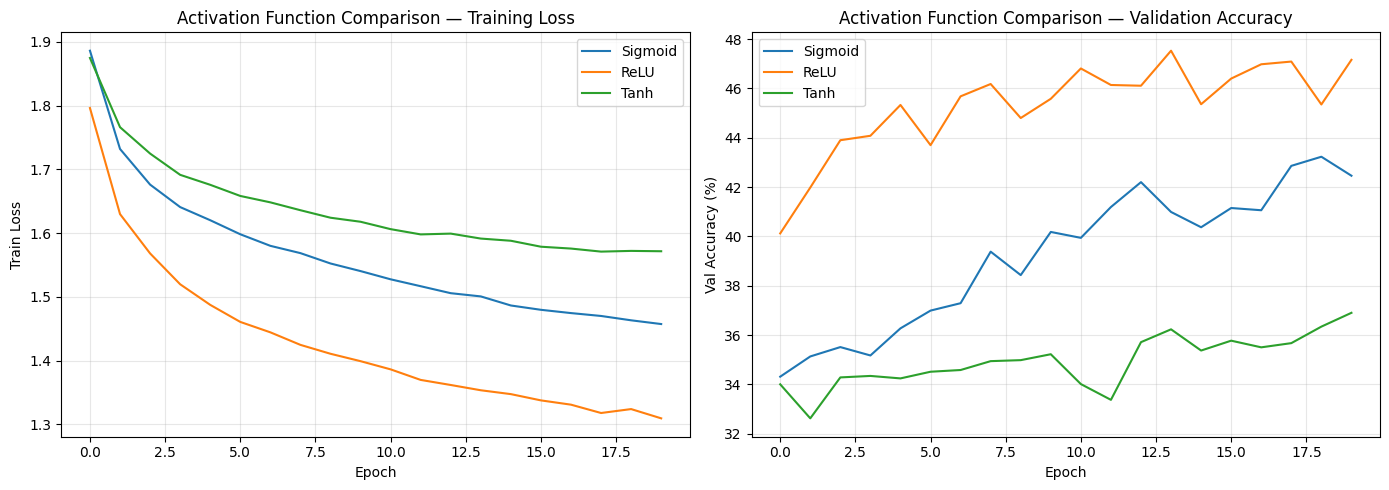

Test 6.2 PASSED.


In [14]:
# DO NOT MODIFY — Test 6.2
assert all(h is not None for h in [history_sigmoid_fair, history_relu_fair, history_tanh_fair])
plot_multiple_histories(
    [history_sigmoid_fair, history_relu_fair, history_tanh_fair],
    ['Sigmoid', 'ReLU', 'Tanh'],
    'Activation Function Comparison'
)
print('Test 6.2 PASSED.')

### Task 6.3 (3 marks): Visualize activation distributions

For each of the three trained models, pass a test batch through and record the output of the **first hidden layer** (after activation). Plot three histograms side by side.

**Hint:** Use `register_forward_hook` on the first activation layer.

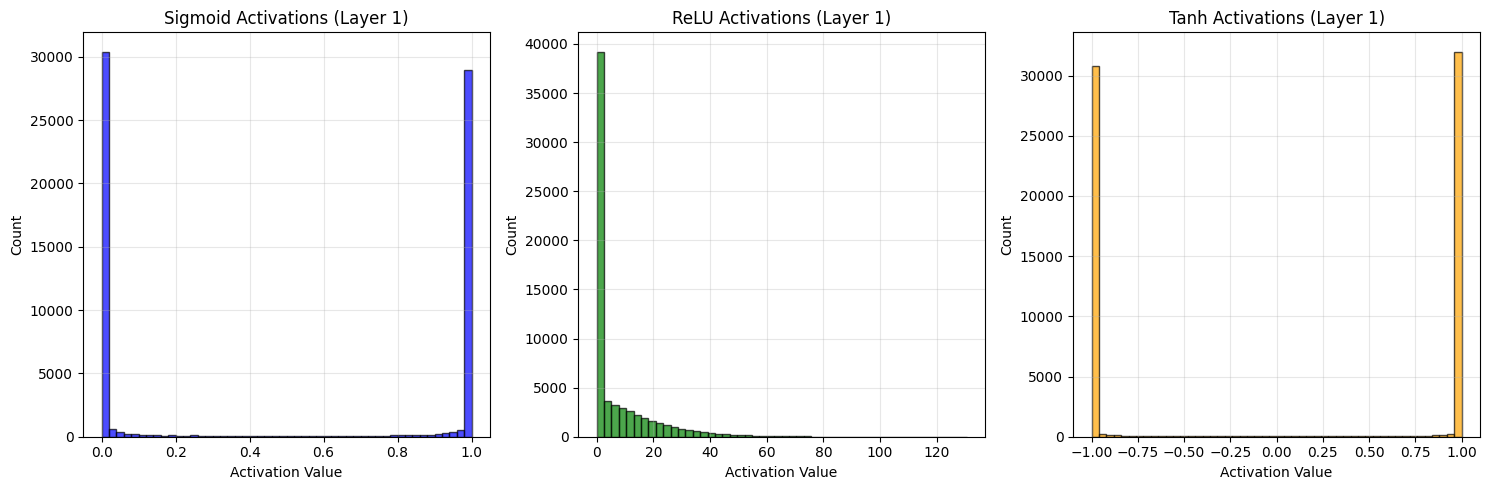

In [15]:
# YOUR CODE HERE

def get_first_layer_activations(model, dataloader, device):
    """Pass data through first layer and return activations."""
    model.eval()
    with torch.no_grad():
        inputs, _ = next(iter(dataloader))
        inputs = inputs.to(device)
        
        # Manually compute first hidden layer output
        x = model.flatten(inputs)
        x = model.fc1(x)
        activations = model.act1(x)
        
    return activations.cpu().numpy().flatten()

# Get activations from each trained model
act_sigmoid = get_first_layer_activations(model_sigmoid, testloader, device)
act_relu = get_first_layer_activations(model_relu, testloader, device)
act_tanh = get_first_layer_activations(model_tanh, testloader, device)

# Plot three histograms side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.hist(act_sigmoid, bins=50, edgecolor='black', alpha=0.7, color='blue')
ax1.set_xlabel('Activation Value')
ax1.set_ylabel('Count')
ax1.set_title('Sigmoid Activations (Layer 1)')
ax1.grid(True, alpha=0.3)

ax2.hist(act_relu, bins=50, edgecolor='black', alpha=0.7, color='green')
ax2.set_xlabel('Activation Value')
ax2.set_ylabel('Count')
ax2.set_title('ReLU Activations (Layer 1)')
ax2.grid(True, alpha=0.3)

ax3.hist(act_tanh, bins=50, edgecolor='black', alpha=0.7, color='orange')
ax3.set_xlabel('Activation Value')
ax3.set_ylabel('Count')
ax3.set_title('Tanh Activations (Layer 1)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()

# END YOUR CODE

---
## Part 7: Weight Initialization: Why It Matters (10 marks)

Bad initialization can cause activations to vanish or explode, making training impossible.

In [16]:
# DO NOT MODIFY — Deep network and init utilities
class DeepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

def apply_init(model, init_name):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if init_name == 'zeros': nn.init.zeros_(m.weight)
            elif init_name == 'large_random': nn.init.normal_(m.weight, std=1.0)
            elif init_name == 'small_random': nn.init.normal_(m.weight, std=0.001)
            elif init_name == 'kaiming': nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            elif init_name == 'xavier': nn.init.xavier_normal_(m.weight)
            if m.bias is not None: nn.init.zeros_(m.bias)
    return model

### Task 7.1 (5 marks): Visualize forward pass statistics before training

**Without training**, pass one batch through `DeepMLP` and record the **standard deviation of activations** at each ReLU layer for four initializations: `zeros`, `large_random`, `small_random`, `kaiming`.

Plot activation std vs. layer index (use log scale for y-axis).

**Steps:**
1. Implement `get_activation_stats(model, dataloader, device)` — register hooks on ReLU layers, run one batch, return per-layer `(mean, std)`
2. For each init strategy, create a fresh `DeepMLP`, apply init, get stats
3. Plot std per layer

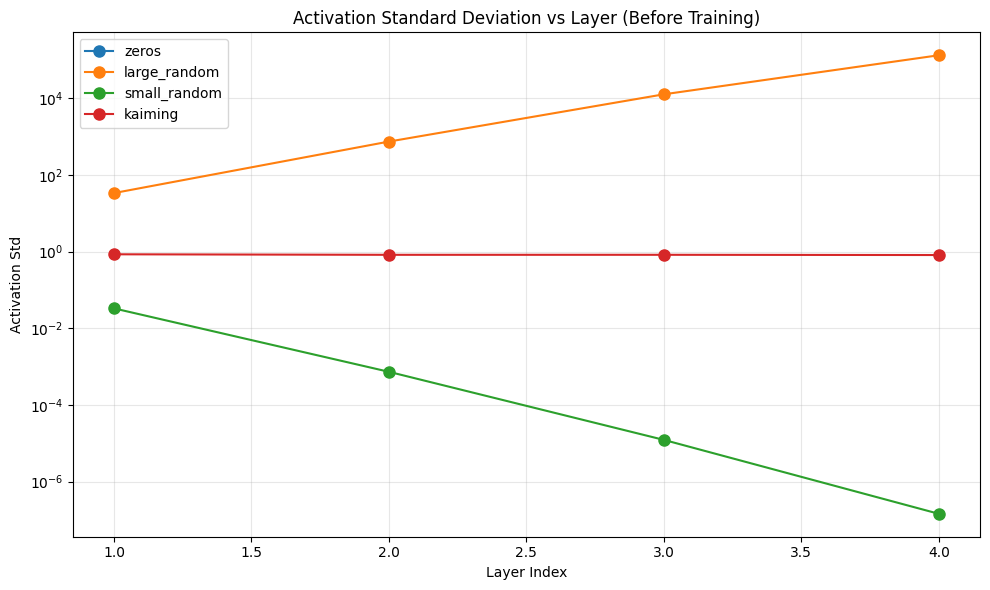

In [17]:
# YOUR CODE HERE

init_strategies = ['zeros', 'large_random', 'small_random', 'kaiming']

def get_activation_stats(model, dataloader, device):
    """Run one batch, return per-ReLU-layer (mean, std) as a list."""
    activations = []
    
    # Hook to capture activations
    def hook_fn(module, input, output):
        activations.append(output.detach().cpu())
    
    # Register hooks on all ReLU layers
    hooks = []
    for module in model.modules():
        if isinstance(module, nn.ReLU):
            hooks.append(module.register_forward_hook(hook_fn))
    
    model.eval()
    with torch.no_grad():
        inputs, _ = next(iter(dataloader))
        inputs = inputs.to(device)
        _ = model(inputs)
    
    # Remove hooks
    for hook in hooks:
        hook.remove()
    
    # Compute (mean, std) for each layer
    stats = []
    for act in activations:
        stats.append((act.mean().item(), act.std().item()))
    
    return stats

# Create figure: plot std per layer for each init
fig, ax = plt.subplots(figsize=(10, 6))

for init_name in init_strategies:
    model = apply_init(DeepMLP(), init_name).to(device)
    stats = get_activation_stats(model, testloader, device)
    stds = [s[1] for s in stats]
    ax.plot(range(1, len(stds) + 1), stds, 'o-', label=init_name, markersize=8)

ax.set_xlabel('Layer Index')
ax.set_ylabel('Activation Std')
ax.set_title('Activation Standard Deviation vs Layer (Before Training)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

# END YOUR CODE

In [ ]:
# DO NOT MODIFY — Test 7.1
model_k = apply_init(DeepMLP(), 'kaiming').to(device)
stats_k = get_activation_stats(model_k, testloader, device)
assert stats_k is not None and len(stats_k) >= 3
assert stats_k[0][1] > 0.01 and stats_k[-1][1] > 0.01, 'Kaiming should keep stds reasonable.'
model_z = apply_init(DeepMLP(), 'zeros').to(device)
stats_z = get_activation_stats(model_z, testloader, device)
assert stats_z[-1][1] < 0.01, 'Zero init should produce near-zero activations.'
print('Test 7.1 PASSED.')

Test 7.1 PASSED.


### Task 7.2 (5 marks): Xavier vs Kaiming with different activations

Train four models (15 epochs, Adam lr=0.001):

| | Tanh | ReLU |
|---|---|---|
| Xavier | ✓ | ✓ |
| Kaiming | ✓ | ✓ |

Create `DeepMLPCustom(activation)` that accepts `'relu'` or `'tanh'`. Store histories in `init_act_histories` dict with keys like `'Xavier+tanh'`.

In [ ]:
# YOUR CODE HERE

class DeepMLPCustom(nn.Module):
    def __init__(self, activation='relu'):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3072, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 128)
        self.fc5 = nn.Linear(128, 10)
        
        if activation == 'relu':
            self.act = nn.ReLU()
        elif activation == 'tanh':
            self.act = nn.Tanh()
        
        self.activation_type = activation

    def forward(self, x):
        x = self.flatten(x)
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.act(self.fc3(x))
        x = self.act(self.fc4(x))
        return self.fc5(x)

def apply_custom_init(model, init_name):
    """Apply Xavier or Kaiming initialization."""
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if init_name == 'xavier':
                nn.init.xavier_normal_(m.weight)
            elif init_name == 'kaiming':
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return model

init_act_histories = {}

# Train 4 combinations: Xavier+tanh, Xavier+relu, Kaiming+tanh, Kaiming+relu
configs = [
    ('Xavier', 'xavier', 'tanh'),
    ('Xavier', 'xavier', 'relu'),
    ('Kaiming', 'kaiming', 'tanh'),
    ('Kaiming', 'kaiming', 'relu'),
]

for init_label, init_name, act_name in configs:
    key = f'{init_label}+{act_name}'
    print(f'Training {key}...')
    
    model = DeepMLPCustom(activation=act_name)
    model = apply_custom_init(model, init_name).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = train_and_log(model, trainloader, testloader, criterion, optimizer, 
                           epochs=15, device=device, verbose=False)
    init_act_histories[key] = history
    print(f'  Final val acc: {history["val_acc"][-1]:.1f}%')

# END YOUR CODE

Training Xavier+tanh...
  Final val acc: 38.4%
Training Xavier+relu...
  Final val acc: 48.3%
Training Kaiming+tanh...
  Final val acc: 37.5%
Training Kaiming+relu...
  Final val acc: 46.8%


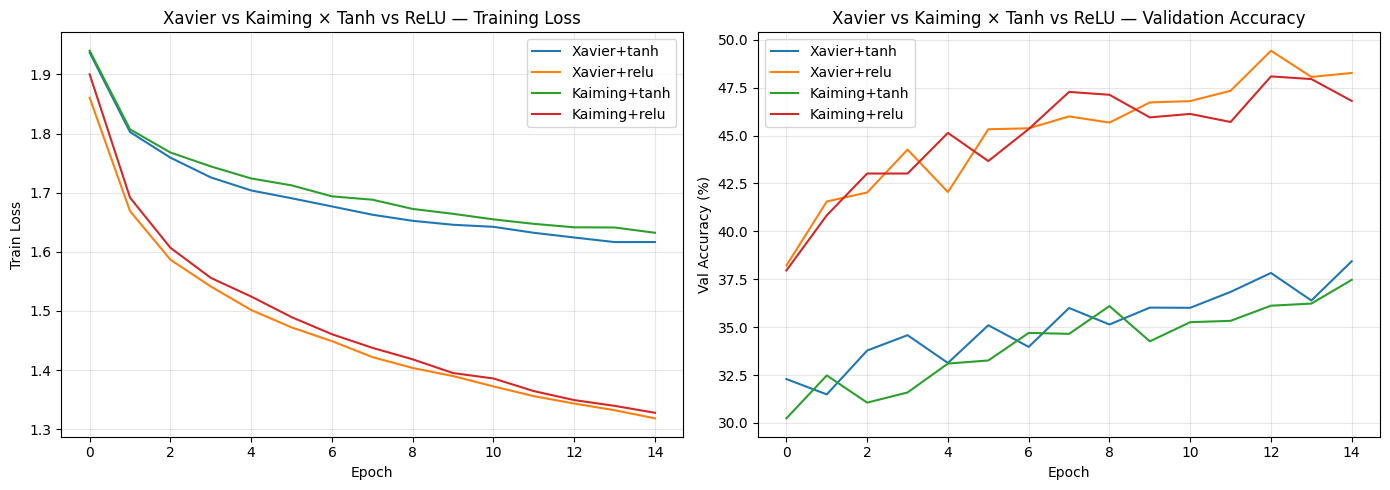

Xavier+tanh          — final val acc: 38.4%
Xavier+relu          — final val acc: 48.3%
Kaiming+tanh         — final val acc: 37.5%
Kaiming+relu         — final val acc: 46.8%
Test 7.2 PASSED.


In [ ]:
# DO NOT MODIFY — Test 7.2
assert len(init_act_histories) == 4, f'Expected 4 configs, got {len(init_act_histories)}'
plot_multiple_histories(list(init_act_histories.values()), list(init_act_histories.keys()),
                       'Xavier vs Kaiming × Tanh vs ReLU')
for name, h in init_act_histories.items():
    print(f'{name:20s} — final val acc: {h["val_acc"][-1]:.1f}%')
print('Test 7.2 PASSED.')

---
## Part 8: Batch Normalization (10 marks)

Batch Normalization normalizes activations layer-by-layer, smoothing the loss landscape and enabling higher learning rates.

### Task 8.1 (5 marks): Define DeepMLPWithBN and test batch size sensitivity

Define `DeepMLPWithBN` — same architecture as `DeepMLP` but with `BatchNorm1d` after each Linear (before ReLU).

Train with three batch sizes: **4, 32, 128** (15 epochs each, Adam lr=0.001). Store in `bn_batch_histories` dict keyed by batch size.

**Why this matters:** BN computes mean/variance over the batch — with very small batches, these statistics become noisy.

In [ ]:
# YOUR CODE HERE
from torch.nn import BatchNorm1d

class DeepMLPWithBN(nn.Module):
    def __init__(self):
        super().__init__()
        # DeepMLP + BatchNorm1d after each Linear, before ReLU
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 1024), nn.BatchNorm1d(1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

batch_sizes_to_test = [4, 32, 128]
bn_batch_histories = {}

for bs in batch_sizes_to_test:
    model = DeepMLPWithBN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_loader = DataLoader(trainset, batch_size=bs, shuffle=True)
    test_loader = DataLoader(testset, batch_size=bs, shuffle=False)
    history = train_and_log(model, train_loader, test_loader, criterion, optimizer, epochs=15, device=device)
    bn_batch_histories[bs] = history

# END YOUR CODE

Epoch   1/15 | Train Loss 2.1345 Acc 20.8% | Val Loss 1.9728 Acc 31.5% | LR 0.001000
Epoch   2/15 | Train Loss 2.0458 Acc 25.1% | Val Loss 1.9234 Acc 33.5% | LR 0.001000
Epoch   3/15 | Train Loss 2.0015 Acc 27.2% | Val Loss 1.8305 Acc 35.8% | LR 0.001000
Epoch   4/15 | Train Loss 1.9808 Acc 28.4% | Val Loss 1.8371 Acc 35.8% | LR 0.001000
Epoch   5/15 | Train Loss 1.9569 Acc 29.2% | Val Loss 1.7658 Acc 40.0% | LR 0.001000
Epoch   6/15 | Train Loss 1.9443 Acc 29.8% | Val Loss 1.7440 Acc 40.6% | LR 0.001000
Epoch   7/15 | Train Loss 1.9244 Acc 30.8% | Val Loss 1.7463 Acc 40.9% | LR 0.001000
Epoch   8/15 | Train Loss 1.9204 Acc 31.1% | Val Loss 1.7635 Acc 40.6% | LR 0.001000
Epoch   9/15 | Train Loss 1.9021 Acc 31.8% | Val Loss 1.7851 Acc 41.0% | LR 0.001000
Epoch  10/15 | Train Loss 1.8980 Acc 32.0% | Val Loss 1.7058 Acc 41.9% | LR 0.001000
Epoch  11/15 | Train Loss 1.8855 Acc 32.5% | Val Loss 1.7350 Acc 40.8% | LR 0.001000
Epoch  12/15 | Train Loss 1.8864 Acc 32.7% | Val Loss 1.7413 Acc 

In [ ]:
# DO NOT MODIFY — Test 8.1
assert len(bn_batch_histories) == 3
for bs in batch_sizes_to_test:
    print(f'Batch size {bs:3d} — final val acc: {bn_batch_histories[bs]["val_acc"][-1]:.1f}%')
plot_multiple_histories(
    [bn_batch_histories[bs] for bs in batch_sizes_to_test],
    [f'BS={bs}' for bs in batch_sizes_to_test],
    'BN Batch Size Sensitivity'
)
print('Test 8.1 PASSED.')

### Task 8.2 (5 marks): Train vs. eval mode — a common bug

BN behaves differently in `.train()` vs `.eval()` mode:
- **Train mode:** Uses batch statistics (mean/var of current batch)
- **Eval mode:** Uses running statistics (accumulated during training)

Train a `DeepMLPWithBN` for 15 epochs, then evaluate accuracy in both modes. Store in `acc_eval_mode` and `acc_train_mode`.

**Think about:** Why might accuracy differ? Which is correct for deployment?

In [ ]:
# YOUR CODE HERE

acc_eval_mode = None
acc_train_mode = None

# END YOUR CODE

print(f'Accuracy with model.eval(): {acc_eval_mode:.1f}%')
print(f'Accuracy with model.train(): {acc_train_mode:.1f}%')

---
## Part 9: Dropout and Regularization (10 marks)

Dropout randomly zeroes neurons during training, forcing the network to learn redundant representations.

### Task 9.1 (10 marks): Dropout experiment: finding the sweet spot

Define `DeepMLPWithDropout`: same as `DeepMLPWithBN` but with `Dropout(rate)` after each ReLU.

Train four models (30 epochs, Adam lr=0.001) with dropout rates: **0.0, 0.2, 0.5, 0.8**. Store in `dropout_histories` dict.

In [19]:
# YOUR CODE HERE

class DeepMLPWithDropout(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 1024), nn.BatchNorm1d(1024), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dropout_rates = [0.0, 0.2, 0.5, 0.8]
dropout_histories = {}

for dr in dropout_rates:
    model = DeepMLPWithDropout(dropout_rate=dr).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = train_and_log(model, trainloader, testloader, criterion, optimizer, epochs=30, device=device)
    dropout_histories[dr] = history

# END YOUR CODE

inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   1/30 | Train Loss 1.7935 Acc 34.8% | Val Loss 1.5842 Acc 42.6% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   4/30 | Train Loss 1.4736 Acc 47.0% | Val Loss 1.3671 Acc 50.7% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   7/30 | Train Loss 1.3722 Acc 50.4% | Val Loss 1.3047 Acc 53.2% | LR 0.001000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on 

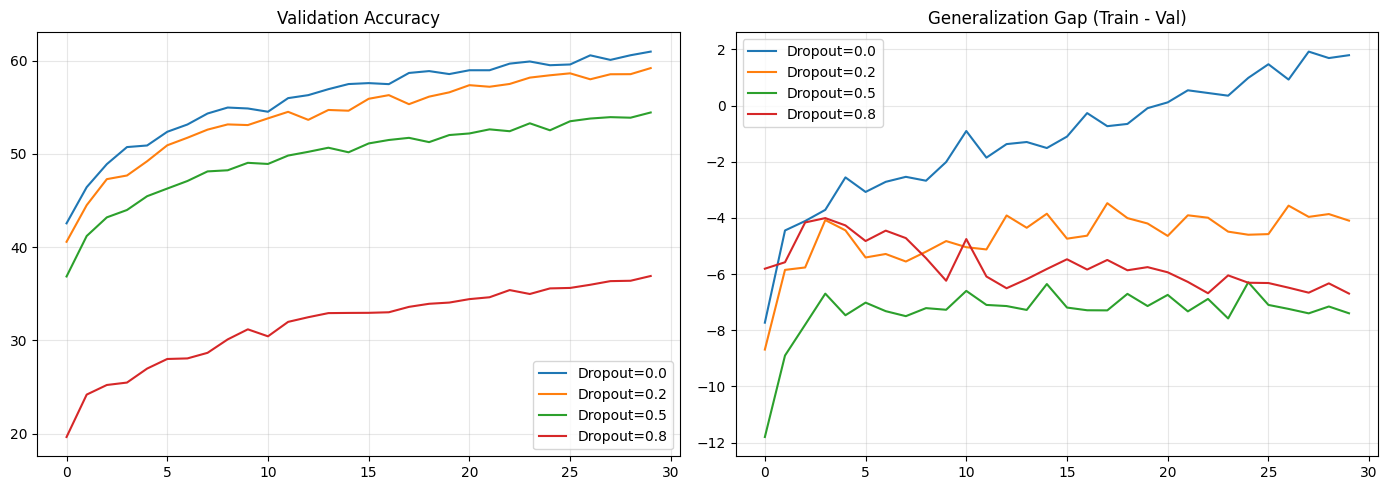

Dropout=0.0 — Train: 62.8%, Val: 61.0%
Dropout=0.2 — Train: 55.1%, Val: 59.2%
Dropout=0.5 — Train: 47.1%, Val: 54.5%
Dropout=0.8 — Train: 30.2%, Val: 36.9%
Test 9.1 PASSED.


In [20]:
# DO NOT MODIFY — Test 9.1
assert len(dropout_histories) == 4
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for dr in dropout_rates:
    h = dropout_histories[dr]
    ax1.plot(h['val_acc'], label=f'Dropout={dr}')
    gap = [t - v for t, v in zip(h['train_acc'], h['val_acc'])]
    ax2.plot(gap, label=f'Dropout={dr}')
ax1.set_title('Validation Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title('Generalization Gap (Train - Val)'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
for dr in dropout_rates:
    h = dropout_histories[dr]
    print(f'Dropout={dr:.1f} — Train: {h["train_acc"][-1]:.1f}%, Val: {h["val_acc"][-1]:.1f}%')
print('Test 9.1 PASSED.')

---
## Part 10: Best MLP Challenge (20 marks)

You now have all the building blocks: architecture design, loss functions, optimizers, activation functions, initialization, batch normalization, dropout, and data augmentation. In this final part, you combine everything to build the **best MLP you can** on CIFAR-10.

### The Scientific Approach

Rather than guessing randomly, treat this as a systematic engineering exercise:

1. **Start with a strong baseline** — use what you learned in Parts 6–9 (BN + Dropout + Kaiming init + a good activation).
2. **Change one thing at a time** — this is called an *ablation study*. It's how real ML research isolates what works.
3. **Log everything** — record what you tried, what worked, and what didn't.

### Techniques to consider

- **Architecture:** Wider layers, deeper networks, skip/residual connections
- **Activation:** ReLU, ELU, LeakyReLU
- **Optimizer:** Adam, SGD+Momentum, AdamW (with weight decay)
- **Learning rate scheduling:** `CosineAnnealingLR`, `ReduceLROnPlateau`, warmup
  ```python
  scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
  history = train_and_log(model, trainloader, testloader, criterion, optimizer, epochs, device, scheduler=scheduler)
  ```
- **Regularization:** Dropout rate, weight decay, data augmentation strength
- **Training duration:** More epochs with LR decay often helps

### Why this approach scales

This systematic methodology: baseline → controlled experiments → documentation, is exactly how teams at Google, Meta, and OpenAI develop models. A well-documented negative result ("I tried X, it didn't help because Y") is more valuable than an unexplained accuracy number. Your writeup is graded as much as your accuracy.

### No convolutional layers allowed.

### Task 10.1 (20 marks): Design, train, and document your best MLP

**Deliverables:**
1. A `BestMLPModel` class (no Conv layers)
2. Training code that produces `history_best`
3. A detailed **Writeup** (in the markdown cell below) documenting:
   - Your baseline and final architecture
   - Each experiment you tried (what, why, result)
   - Training recipe (optimizer, LR schedule, epochs, augmentation)
   - What worked, what didn't, and your hypotheses for why
   - Why MLPs have a fundamental accuracy ceiling on CIFAR-10

**Grading:**

| Component | Marks |
|-----------|-------|
| Accuracy: ≥ 62% | 5 |
| Accuracy: ≥ 58% (if <62%) | 3 |
| Accuracy: ≥ 54% (if <58%) | 2 |
| Accuracy: < 54% | 1 |
| Code quality and architecture design | 5 |
| Writeup: experiments documented | 5 |
| Writeup: analysis and insights | 5 |

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import time
import copy
import math
from collections import defaultdict
from typing import List, Dict, Any
from math import log
from torch.nn import ELU

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transform_basic = transforms.Compose([transforms.ToTensor()])
trainset_raw = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_basic)
testset_raw = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_basic)

# Stack all images into a single tensor: (N, C, H, W)
all_images = torch.stack([trainset_raw[i][0] for i in range(len(trainset_raw))])

# Compute mean and std per channel (over N, H, W dimensions)
# all_images shape: (50000, 3, 32, 32)
channel_means = tuple(all_images.mean(dim=(0, 2, 3)).tolist())  # mean over batch, height, width
channel_stds = tuple(all_images.std(dim=(0, 2, 3)).tolist())    # std over batch, height, width

# END YOUR CODE

print(f'Channel means: {channel_means}')
print(f'Channel stds: {channel_stds}')
# Define transform pipelines using the computed channel statistics
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(channel_means, channel_stds)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(channel_means, channel_stds)
])

# Create datasets with the new transforms
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Create data loaders with batch_size=128
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=4)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=4)


# DO NOT MODIFY — Utility functions used throughout the project

def train_one_epoch(model, trainloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0; correct = 0; total = 0
    for i, (inputs, labels) in enumerate(trainloader):            
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        if i == 0:
            print(f"inputs on device: {inputs.device}. labels on device: {labels.device}. model on device: {next(model.parameters()).device}")
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total

def evaluate(model, testloader, criterion, device):
    model.eval()
    running_loss = 0.0; correct = 0; total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total

def train_and_log(model, trainloader, testloader, criterion, optimizer,
                  epochs, device, scheduler=None, verbose=True):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, trainloader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, testloader, criterion, device)
        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
        if verbose and (epoch % max(1, epochs // 10) == 0 or epoch == epochs - 1):
            print(f'Epoch {epoch+1:3d}/{epochs} | '
                  f'Train Loss {train_loss:.4f} Acc {train_acc:.1f}% | '
                  f'Val Loss {val_loss:.4f} Acc {val_acc:.1f}% | '
                  f'LR {current_lr:.6f}')
    return history

def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{title} — Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_multiple_histories(histories, labels, title='Comparison'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for h, label in zip(histories, labels):
        ax1.plot(h['train_loss'], label=f'{label}')
        ax2.plot(h['val_acc'], label=f'{label}')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Train Loss')
    ax1.set_title(f'{title} — Training Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Accuracy (%)')
    ax2.set_title(f'{title} — Validation Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

print('Utilities loaded.')

in_features = 3072
out_features = 10
activation = nn.ReLU()
epochs = 30
lr = 1e-3
criterion = nn.CrossEntropyLoss()

def create_sequential_model(layers: List[int], activation: nn.Module) -> nn.Sequential:
    """Create a sequential MLP given a list of layer sizes for CIFAR-10 images."""
    modules = [nn.Flatten()]  # flatten (B, 3, 32, 32) -> (B, 3072)
    for in_f, out_f in zip(layers[:-1], layers[1:]):
        modules.append(nn.Linear(in_f, out_f))
        # Add activation after every layer except the last
        if out_f != layers[-1]:
            modules.append(activation)
    return nn.Sequential(*modules)

    

def get_activation_list() -> List[nn.Module]:
    """ Create a list of activations for the model """
    return [nn.ReLU(), nn.ELU(), nn.LeakyReLU(0.1)]

def create_layers(in_features: int, out_features: int, reduction_factor: int = 2) -> List[int]:
    """Create a list of layer sizes from in_features down to out_features."""
    layers = [in_features]
    current = in_features
    while current // reduction_factor > out_features:
        current = current // reduction_factor
        layers.append(current)
    if layers[-1] != out_features:
        layers.append(out_features)
    return layers


activations : List[nn.Module] = [nn.ReLU(), nn.ELU(), nn.LeakyReLU(0.1)]

reduction_factors = [2, 3, 4]


def create_best_mlp(in_features: int, out_features: int) -> Dict[str, Any]:
    training_histories = {}

    for reduction_factor in reduction_factors:
        for activation in activations:
            layers = create_layers(in_features, out_features, reduction_factor)

            for opt_name in ["SGD", "Adam", "AdamW"]:
                for sched_name in ["Cosine", "Plateau"]:

                    # fresh model every run
                    model = create_sequential_model(layers, activation).to(device)

                    # fresh optimizer every run
                    if opt_name == "SGD":
                        optimizer = optim.SGD(
                            model.parameters(),
                            lr=0.1,
                            momentum=0.9,
                            weight_decay=5e-4
                        )
                    elif opt_name == "Adam":
                        optimizer = optim.Adam(model.parameters(), lr=1e-3)
                    else:
                        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

                    # fresh scheduler every run
                    if sched_name == "Cosine":
                        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
                    else:
                        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                            optimizer, mode='min', factor=0.1, patience=10
                        )

                    run_name = f"rf={reduction_factor}, act={activation.__class__.__name__}, opt={opt_name}, sched={sched_name}"

                    history = train_and_log(
                        model, trainloader, testloader, criterion, optimizer,
                        epochs, device, scheduler=scheduler
                    )

                    training_histories[run_name] = history

    return training_histories

Channel means: (0.491400808095932, 0.48215898871421814, 0.44653093814849854)
Channel stds: (0.24703224003314972, 0.24348513782024384, 0.26158785820007324)
Utilities loaded.


In [59]:
histories = create_best_mlp(3072, 10)

inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   1/30 | Train Loss 2.2439 Acc 12.7% | Val Loss 2.0807 Acc 18.4% | LR 0.100000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   4/30 | Train Loss 1.9421 Acc 24.3% | Val Loss 1.9260 Acc 24.0% | LR 0.097553
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   7/30 | Train Loss 1.8284 Acc 30.4% | Val Loss 1.7969 Acc 32.0% | LR 0.090451
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on 

In [10]:
for config, history in histories.items():
    print(config)
    train_loss = history['train_loss']
    train_acc = history['train_acc']
    val_loss = history['val_loss']
    val_acc = history['val_acc']
    lr = history['lr']
    print(f'Train Loss: {train_loss[-1]:.4f} | Train Acc: {train_acc[-1]:.1f}% | Val Loss: {val_loss[-1]:.4f} | Val Acc: {val_acc[-1]:.1f}% | LR: {lr[-1]:.6f}')
    print('-' * 100)

"""
rf=3, act=ELU, opt=SGD, sched=Cosine
Train Loss: 1.0678 | Train Acc: 61.8% | Val Loss: 1.2137 | Val Acc: 57.6% | LR: 0.000274
"""

NameError: name 'histories' is not defined

In [11]:
layers : List[int] = create_layers(3072, 10, 3)
net = create_sequential_model(layers, nn.ELU())
print(net)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=1024, bias=True)
  (2): ELU(alpha=1.0)
  (3): Linear(in_features=1024, out_features=341, bias=True)
  (4): ELU(alpha=1.0)
  (5): Linear(in_features=341, out_features=113, bias=True)
  (6): ELU(alpha=1.0)
  (7): Linear(in_features=113, out_features=37, bias=True)
  (8): ELU(alpha=1.0)
  (9): Linear(in_features=37, out_features=12, bias=True)
  (10): ELU(alpha=1.0)
  (11): Linear(in_features=12, out_features=10, bias=True)
)


In [8]:
# YOUR CODE HERE
epochs = 200
class BestMLPModel(nn.Module):
    def __init__(self, activation_fn: nn.Module):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 1024),
            activation_fn(),
            nn.Dropout(0.2),
            nn.Linear(1024, 341),
            activation_fn(),
            nn.Dropout(0.2),
            nn.Linear(341, 113),
            activation_fn(),
            nn.Dropout(0.2),
            nn.Linear(113, 37),
            activation_fn(),
            nn.Dropout(0.2),
            nn.Linear(37, 12),
            activation_fn(),
            nn.Linear(12, 10),
        )

    def forward(self, x):
        return self.net(x)
def apply_custom_init(model, init_name):
    """Apply Xavier or Kaiming initialization."""
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if init_name == 'xavier':

                nn.init.xavier_normal_(m.weight)
            elif init_name == 'kaiming':
                # assert mot elu
                assert not isinstance(m.activation_fn, nn.ELU), "ELU is not supported for Kaiming initialization"
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return model

best_model = BestMLPModel(activation_fn=lambda: nn.ELU(alpha=1.0)).to(device)
best_model = apply_custom_init(best_model, 'xavier')
optimizer = optim.SGD(best_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
history_best = train_and_log(best_model, trainloader, testloader, criterion, optimizer, epochs, device, scheduler=scheduler)

# END YOUR CODE

inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
Epoch   1/200 | Train Loss 1.9994 Acc 26.8% | Val Loss 1.7784 Acc 36.6% | LR 0.010000
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
inputs on device: cuda:0. labels on device: cuda:0. model on device: cuda:0
in

Best validation accuracy: 62.0%
Final validation accuracy: 62.0%
Accuracy grade: 5/5 — Excellent!


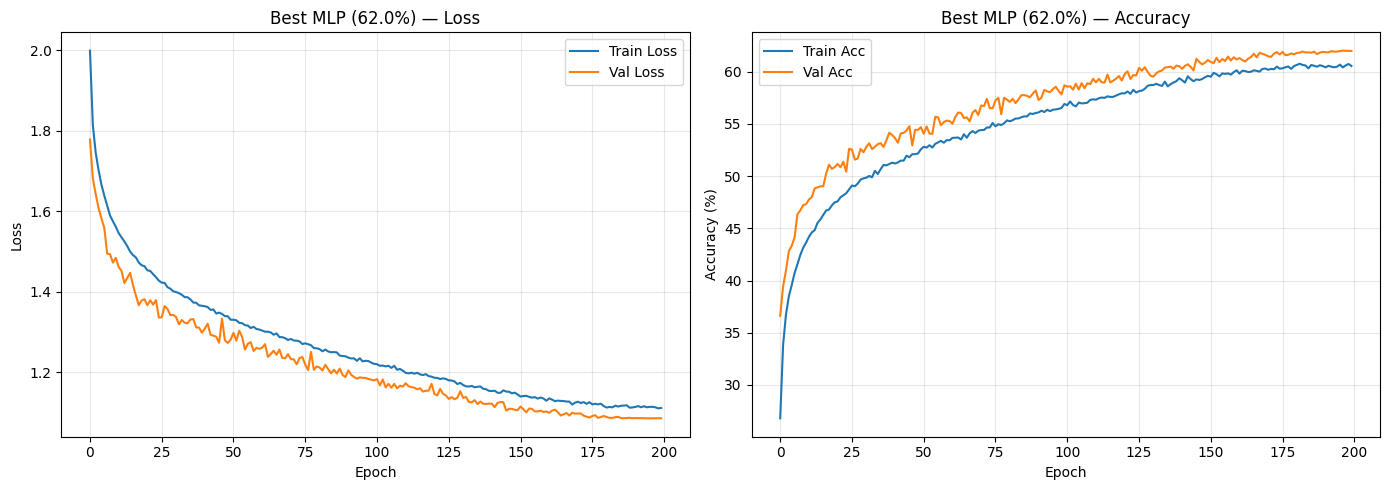

Test 10.1 PASSED.


In [9]:
# DO NOT MODIFY — Test 10.1
assert history_best is not None, 'Train your best model.'
for m in best_model.modules():
    assert not isinstance(m, (nn.Conv2d, nn.Conv1d)), 'No convolutional layers allowed!'
best_acc = max(history_best['val_acc']); final_acc = history_best['val_acc'][-1]
print(f'Best validation accuracy: {best_acc:.1f}%')
print(f'Final validation accuracy: {final_acc:.1f}%')
if best_acc >= 62: print('Accuracy grade: 5/5 — Excellent!')
elif best_acc >= 58: print('Accuracy grade: 3/5 — Great job.')
elif best_acc >= 54: print('Accuracy grade: 2/5 — Good effort.')
else: print(f'Accuracy grade: 1/5 — Keep tuning.')
plot_history(history_best, f'Best MLP ({best_acc:.1f}%)')
print('Test 10.1 PASSED.')

### Task 10.1 Writeup

*Document your approach below. This writeup is worth 10 of the 20 marks.*

**Baseline:**
- *Describe your starting architecture and training setup*

**Experiments tried:**

| # | What I changed | Why | Result (val acc) | Keep? |
|---|---------------|-----|-----------------|-------|
| 1 | *Did a sweep over base combinations after 30 epochs, got this rf=3, act=ELU, opt=SGD, sched=Cosine* | *Wanted to see what the best base model was* | *57%* | *Yes* |
| 2 |*Tweaking best model from prev experiment, ran for 50 epochs* |*Wanted to see the model after 30 epochs* |*59.9%* |*yes*|
| 3 |*Try 80 epochs* | *model seemed to be getting if given more time*|*60.5*|*yes*|
| 4 |*Adding dropout* |*Noticed training accuracy was lower then eval, added*|*60.9*|*yes*|
| 5 |*try for 150 epochs* |*Dropout prevetned overfitting, we can afford more* | *63.6*|*yes* |
| 6 |*Adding more droupout since we overfit a little after 100 epochs* |*We were overfitting* |*62.0* |*no* |
**Final recipe:**
- *Architecture:*
- *Optimizer:*
- *LR schedule:*
- *Epochs:*

**What didn't work and why:**

**Why MLPs have a ceiling on CIFAR-10:**

---
## Bonus: Reflection Questions (5 marks — 1 mark each)

### Bonus Q1 (1 mark)

Identify the three single changes (from any part of this project) that yielded the largest accuracy improvements. Categorize each as: (a) increased model capacity, (b) improved optimization, or (c) reduced overfitting.

*Your answer here*

### Bonus Q2 (1 mark)

Give three distinct reasons why training loss going to 0 does NOT mean the model has 'learned'. For each, describe what the validation curve would look like.

*Your answer here*

### Bonus Q3 (1 mark)

What features can an MLP learn from flattened pixels? What can it NOT learn efficiently? Why do CNNs have such an advantage?

*Your answer here*

### Bonus Q4 (1 mark)

Zhang et al. (2017) showed neural networks can memorize random labels. Yet the same architectures generalize well on real data. Explain this apparent paradox.

*Your answer here*

### Bonus Q5 (1 mark)

If you could add only ONE technique to a vanilla deep network (no BN, no dropout, default init, constant LR, no augmentation), which gives the single largest improvement? Choose from: (a) Batch Normalization (b) Dropout (c) Kaiming initialization (d) LR scheduling (e) Data augmentation. Justify.

*Your answer here*

---
### Summary

In [ ]:
# DO NOT MODIFY — Final summary
print('=' * 60)
print('PROJECT SUMMARY')
print('=' * 60)
results = []
if 'history_fixed_linear' in dir() and history_fixed_linear:
    results.append(('Linear Classifier', history_fixed_linear['val_acc'][-1]))
if 'history_mlp' in dir() and history_mlp:
    results.append(('MLP', history_mlp['val_acc'][-1]))
if 'history_best' in dir() and history_best:
    results.append(('Best MLP Model', max(history_best['val_acc'])))
for name, acc in results:
    print(f'{name:30} {acc:11.1f}%')
print('=' * 60)
print('END OF PROJECT')